In [ ]:
#!pip install devito
#!pip install CoolProp

### Importações

In [ ]:
import CoolProp.CoolProp as CP
import numpy as np
from devito import *
from constantes import *
from radiacao import *

import matplotlib.pyplot       as plt
import matplotlib.ticker       as mticker
from   mpl_toolkits.axes_grid1 import make_axes_locatable
from   matplotlib              import cm
from   matplotlib              import ticker

### Definições

In [ ]:
class Topo(SubDomain):
    name = 'topo'
    def define(self, dimensions):
        x, z = dimensions
        return {x: x, z: ('left', 1)} # 'left' indica o início de z, espessura de 1 nó

#z=z.max
class Fundo(SubDomain):
    name = 'fundo'
    def define(self, dimensions):
        x, z = dimensions
        return {x: x, z: ('right', 1)}

class Meio(SubDomain):
    name = 'meio'
    def define(self, dimensions):
        x, z = dimensions
        # ('middle', 1, 1) significa: pegue o meio, pulando 1 nó no começo e 1 nó no final
        return {x: x, z: ('middle', 1, 1)}

#grid2D
x = SpaceDimension(name='x') #Na lógica do Devito, o segundo termo do "Grid" é internamente chamado de "y" irrelevante do que você escrever
z = SpaceDimension(name='z') #Utilizar SpaceDimension resolve este problema

grid = Grid(shape=(nx, nz), extent=(L, delta_g), dimensions=(x,z))
t = grid.stepping_dim
dx, dz = grid.spacing

# Instanciando os subdomínios
topo = Topo(grid=grid)
fundo = Fundo(grid=grid)
meio = Meio(grid=grid)

### Definição de Temperaturas e Fatores

In [ ]:
# Temperaturas
TemperaturaVidro = TimeFunction(name='T_g',
                                grid=grid,
                                dimensions=(grid.time_dim, x, z),
                                save=nt+1, shape=(nt+1, nx, nz),
                                space_order=2)

TemperaturaPlaca = TimeFunction(name='T_p',
                                grid=grid,
                                dimensions=(grid.time_dim, x),
                                save=nt+1, shape=(nt+1, nx),
                                space_order=2)

TemperaturaAr = TimeFunction(name='T_a', grid=grid,
                             dimensions=(grid.time_dim, x),
                             save=nt+1, shape=(nt+1, nx),
                             space_order=2)

TemperaturaAmbiente = TimeFunction(name='T_am',                                 #Alteração na função de temperatura para
                                   grid=grid, dimensions=(grid.time_dim,),      #uma função que possui somente dimensão temporal
                                   save=nt+1, shape=(nt+1,),
                                   time_order=1)

TemperaturaCeu = TimeFunction(name='T_ceu',                                 #Alteração na função de temperatura para
                              grid=grid, dimensions=(grid.time_dim,),      #uma função que possui somente dimensão temporal
                              save=nt+1, shape=(nt+1,),
                              time_order=3)

#Fatores Transferencias de calor dependentes das temperaturas
h_rpg = TimeFunction(name='h_rpg', grid=grid, dimensions=(grid.time_dim, x), shape=(nt+1, nx), space_order=1)
h_rpsky = TimeFunction(name='h_rpsky', grid=grid, dimensions=(grid.time_dim, x), shape=(nt+1, nx))

#Condição inicial (eq. 16) considerando T0 = 35°C
TemperaturaVidro.data_with_halo[:] = 308.15
TemperaturaPlaca.data_with_halo[:] = 308.15
TemperaturaAmbiente.data_with_halo[:] = 308.15
TemperaturaAr.data_with_halo[:] = 308.15

### Equações Diferenciais

In [ ]:
eqCeu = Eq(TemperaturaCeu[t+1], 0.0552*pow(TemperaturaAmbiente[t+1], 1.5)) #Passagem de TemperaturaCeu para ser resolvido pelo operador

# Equações Diferenciais
eq11 = Eq(TemperaturaVidro.dt,
          (k_g/(C_g*ro_g)) * TemperaturaVidro.dz2
          + It_func*alpha_g/(ro_g*C_g*delta_g))

eq12 = Eq(TemperaturaPlaca.dt,
          It_func*tau_g*alpha_p/(ro_p*C_p*l_p)
          + (h_pa/(ro_p*C_p*l_p))*(TemperaturaAr - TemperaturaPlaca)
          - (h_rpsky/(ro_p*C_p*l_p)) * (TemperaturaPlaca - TemperaturaCeu)
          - (h_rpg/(ro_p*C_p*l_p)) * (TemperaturaPlaca - TemperaturaVidro.subs(z, 0)))

eq13 = Eq(TemperaturaAr.dt,
          (-1) * VelocidadeAr * TemperaturaAr.dxl
          + (h_ga*b/(ro_a*C_a*A_C))*(TemperaturaVidro.subs(z, 0) - TemperaturaAr)
          + (h_pa*b/(ro_p*C_p*A_C))*(TemperaturaPlaca - TemperaturaAr))

eq_1 = Eq(TemperaturaVidro.forward,
          solve(eq11, TemperaturaVidro.forward))

eq_2 = Eq(TemperaturaPlaca.forward,
          solve(eq12, TemperaturaPlaca.forward))

eq_3 = Eq(TemperaturaAr.forward,
          solve(eq13, TemperaturaAr.forward))

### Equações Coeficientes de Transferencia

In [ ]:
#Equações dos coeficientes de transf. de calor
eq_rpsky = Eq(h_rpsky.forward,
              sigma * (TemperaturaPlaca**2 + TemperaturaCeu**2)
              * (TemperaturaPlaca + TemperaturaCeu)
              / (1/epslon_p + 1/tau_g - 1))

eq_rpg = Eq(h_rpg.forward,
            sigma * (TemperaturaPlaca**2 + TemperaturaVidro.subs(z, 0)**2)
            * (TemperaturaPlaca + TemperaturaVidro.subs(z, 0))
            / (1/epslon_p + 1/tau_g - 1))

### Condições de Contorno

In [ ]:
#Condições de contorno
eq_entradaAr = Eq(TemperaturaAr.forward.subs(x, 0),                             #A função subs diz onde eu quero
                TemperaturaAmbiente)                                            #que a igualdade seja válida


eq_17 = Eq(TemperaturaVidro.dzr,
           h_ga * (TemperaturaVidro - 308.15)/ k_g,
          subdomain=fundo)

eq_18 = Eq(TemperaturaVidro.dzl,
           h_gam * (- TemperaturaVidro + 308.15)/ k_g,
          subdomain=topo)

'''
eq_4 = Eq(TemperaturaVidro.forward,
          solve(eq_17, TemperaturaVidro.forward),
          subdomain=topo)

eq_5 = Eq(TemperaturaVidro.forward,
          solve(eq_18, TemperaturaVidro.forward),
          subdomain=fundo)
'''

'''
eq_17 = Eq(TemperaturaVidro[t+1, x, z - 1],
          TemperaturaVidro[t+1, x, z + 1] - (2 * dz * h_ga / k_g) * (TemperaturaVidro[t+1, x, z] - 308.15),
          subdomain=topo)                                   #Mandando as eqs de contorno funcionarem somente nas bordas

eq_18 = Eq(TemperaturaVidro[t+1, x, z + 1],
          TemperaturaVidro[t+1, x, z - 1] + (2 * dz * h_gam / k_g) * (308.15 - TemperaturaVidro[t+1, x, z]),
          subdomain=fundo)
'''

### Recebedor e Impressão

In [ ]:
#Recebedor
nrec = 1
rec_T = Receiver(name="rec_T", grid=grid, npoint=nrec, time_range=time_range)
rec_T.coordinates.data[:, 0] = L
rec_T.coordinates.data[:, 1] = 0
rec_term = rec_T.interpolate(expr=TemperaturaVidro.dt)

#Operador
op = Operator([eq_1, eq_2, eq_3,
              eq_entradaAr, eq_17, eq_18,
              eq_rpsky, eq_rpg, eqCeu,] + rec_term)

op(dt=dt, time=nt-1)

Operator `Kernel` ran in 1.11 s
INFO:Devito:Operator `Kernel` ran in 1.11 s


PerformanceSummary([(PerfKey(name='section0', rank=None),
                     PerfEntry(time=0.33093599999823875, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])),
                    (PerfKey(name='section1', rank=None),
                     PerfEntry(time=0.18305800000015116, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])),
                    (PerfKey(name='section2', rank=None),
                     PerfEntry(time=0.27713299999953406, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])),
                    (PerfKey(name='section3', rank=None),
                     PerfEntry(time=0.12952900000010545, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])),
                    (PerfKey(name='section4', rank=None),
                     PerfEntry(time=0.07119800000004933, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[]))])

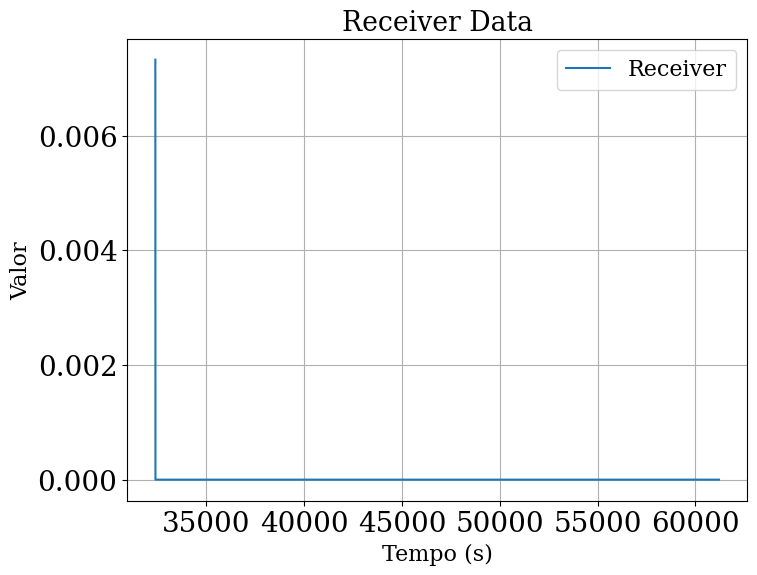

In [ ]:
# Plot Configuration
#==============================================================================
plt.rc('text' , usetex=False)
plt.rc('font' , family='serif')
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)

plt.plot(time_range.time_values[:-1], rec_T.data[:-1], label=f"Receiver")
plt.xlabel("Tempo (s)")
plt.ylabel("Valor")
plt.title("Receiver Data")
plt.legend()
plt.grid()
plt.show()